In [43]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import skewnorm,skew
from scipy.stats import pearsonr
from scipy.linalg import toeplitz
from scipy.interpolate import CubicSpline
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''Statemodels'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
import statsmodels.stats.power as smp
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.outliers_influence import OLSInfluence
from statsmodels.stats.stattools import durbin_watson,omni_normtest,\
                                        jarque_bera
from patsy import dmatrices,dmatrix

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
# model_selection
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import KFold, StratifiedKFold, StratifiedShuffleSplit
from sklearn.model_selection import learning_curve

# Multiclass
from sklearn.multiclass import OneVsOneClassifier

# Base
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.base import clone

# preprocessing
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import PolynomialFeatures

# pipeline
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline

# datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.datasets import make_classification
from sklearn.datasets import load_iris
from sklearn.datasets import load_sample_image

# metrics

from sklearn.metrics import root_mean_squared_error

from sklearn.metrics import mean_squared_error,mean_absolute_error
from sklearn.metrics import confusion_matrix,precision_score,\
                            recall_score,f1_score,\
                            classification_report, accuracy_score,\
                            precision_recall_curve,\
                            roc_curve, roc_auc_score,\
                            ConfusionMatrixDisplay,\
                            root_mean_squared_error                      

# tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz

# linear_model
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import LogisticRegression
#SVM
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

from graphviz import Source

#ensemble
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import BaggingClassifier

#decomposition
from sklearn.decomposition import PCA

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

from sklearn.cluster import MiniBatchKMeans

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
#====================================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras import initializers
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import sigmoid

import sys
from copy import deepcopy

import kagglehub
# =====================================
# caution: path[0] is reserved for script path (or '' in REPL)
sys.path.insert(1, r'C:\Users\TODO\Desktop\Abhi\AI\AI\Math\Hands-On\statemodelsStudy')
from olsRegressionAnalysis import dispAnalysisOfVariance, tableDispFormatt,getInvOfProductMat,\
                                  getRegressionEqn,\
                                  dispReghressionAnalysis,norm_scalling,getCorrelation,\
                                  get_variance_inflation_factors,goodnessOfFitTestOfParams

path = os.path.join(os.getcwd(), 'DataSet', 'AcetyleneData_10_1.txt')

In [44]:
path = os.path.join(os.getcwd(), 'Iris.csv')
df = pd.read_csv(path)
df.drop(['Id'], axis=1, inplace=True)
df.columns

Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [45]:
X = df.drop(['Species'], axis=1, inplace=False)
y = df['Species'].map({'Iris-setosa':1,'Iris-versicolor':0,'Iris-virginica':0})

In [46]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shapes
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (120, 4)
Test set size: (30, 4)


In [47]:
target_names = df['Species'].value_counts().index.values.tolist()
target_names

['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']

#### Model with L2 regularizations

Model made with following parameter
- penalty = l2
- tol=0.0001 (Tolrance lavel)
- C=1.0 this default now. We must have change this value
- fit_intercept=True Definetelly We are going to add Intercept term
- class_weight --> We must have lern how to assign weight. Default it's one
- solver:  default= lbfgs
  - Solver lbfgs supports only 'l2' or None penalties
  - For small datasets, ‘liblinear’ is a good choice, whereas ‘sag’ and ‘saga’ are faster for large ones;
    - Need to understand ‘liblinear’ about multiclass problem, small and big dataset
  - ‘newton-cholesky’ is a good choice for n_samples >> n_features * n_classes, especially with one-hot encoded categorical features with rare categories.

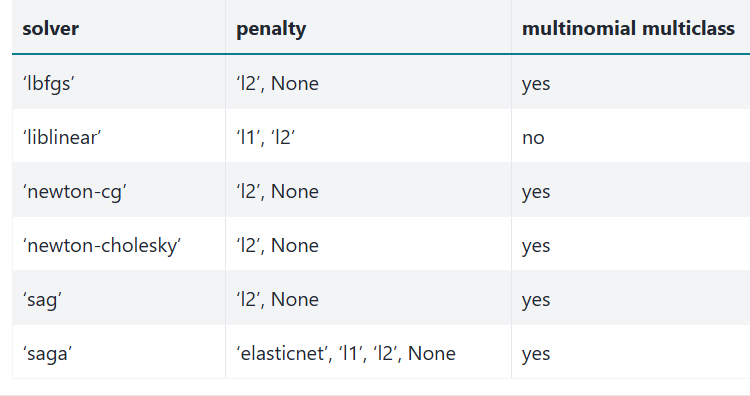

- multi_class: Deprecated since version 1.5



### Check if scalling is required

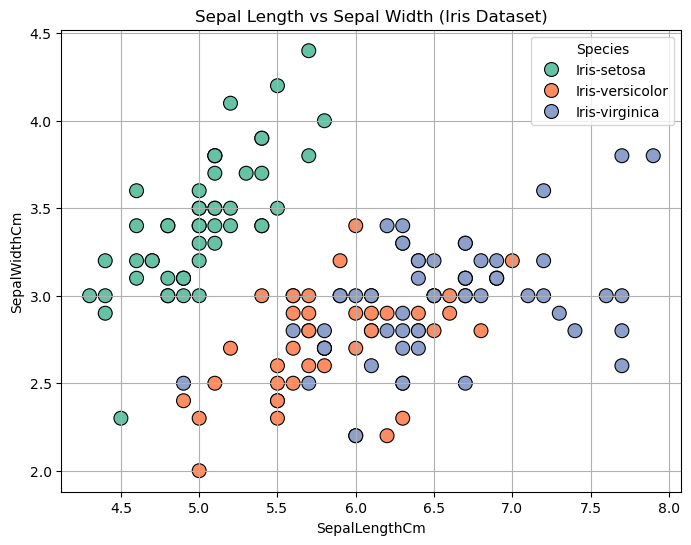

In [48]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x='SepalLengthCm',
    y='SepalWidthCm',
    hue='Species',
    palette='Set2',   
    s=100,
    edgecolor='black',    
)

plt.title('Sepal Length vs Sepal Width (Iris Dataset)')
plt.grid(True)
plt.show()


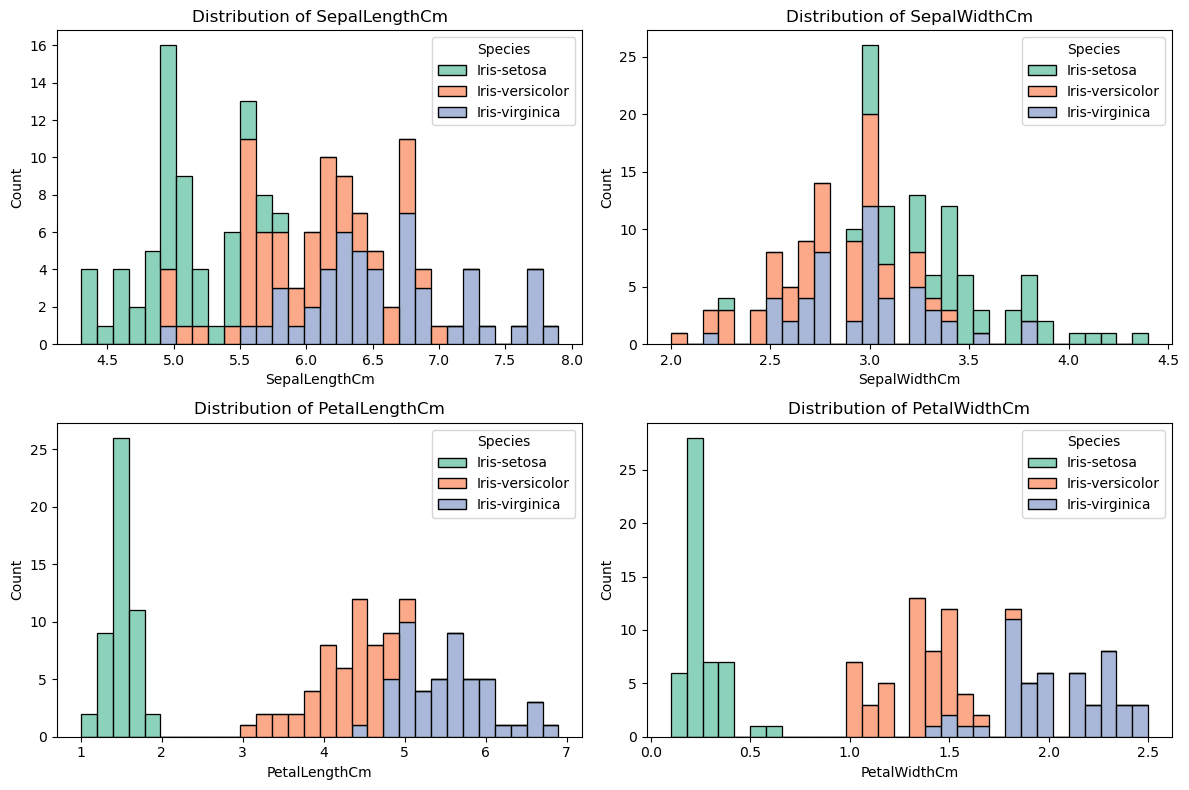

In [49]:
# Plot histograms for each feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = df.columns

for i, ax in enumerate(axes.flat):
    sns.histplot(data=df, x=features[i],bins=30, hue='Species', multiple='stack', ax=ax, palette='Set2')
    ax.set_title(f'Distribution of {features[i]}')

plt.tight_layout()
plt.show()


So scaling is required when we are processing the dataset normalizations. According hist plot Sepal length varies to 8.0, Petal length varies to 7.0 So We do not required Scaling here.

In [50]:
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='lbfgs',max_iter=200,tol=0.001,fit_intercept=True)
res_l2 = Logistice.fit(X_train, y_train)

In [51]:
res_l2.classes_.size
print(f'Totla number of classes: {res_l2.classes_.size} and classes {res_l2.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2.coef_}')
print(f'Number of features: {res_l2.n_features_in_}')
print(f'Names of features: {res_l2.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2.n_iter_}')

Totla number of classes: 2 and classes [0 1]
Intercept (a.k.a. bias) added to the decision function: [6.11102657]
Coefficient of the features in the decision function [[-0.38399751  0.89314789 -2.22767882 -0.94492546]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[20]


In [52]:
# Predict on test set
y_pred = res_l2.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
dfX = pd.DataFrame({'test':y_test,'pred':y_pred})
dfX['match'] = dfX['test'] == dfX['pred']


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### Change Solver liblinear

In [53]:
Logistice = LogisticRegression(random_state=42,penalty='l1',solver='liblinear',max_iter=200,tol=0.001,fit_intercept=True)
res_l2 = Logistice.fit(X_train, y_train)

In [54]:
res_l2.classes_.size
print(f'Totla number of classes: {res_l2.classes_.size} and classes {res_l2.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2.coef_}')
print(f'Number of features: {res_l2.n_features_in_}')
print(f'Names of features: {res_l2.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2.n_iter_}')

Totla number of classes: 2 and classes [0 1]
Intercept (a.k.a. bias) added to the decision function: [0.]
Coefficient of the features in the decision function [[ 0.          2.35628248 -2.64148647  0.        ]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[13]


In [55]:
# Predict on test set
y_pred = res_l2.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
dfX = pd.DataFrame({'test':y_test,'pred':y_pred})
dfX['match'] = dfX['test'] == dfX['pred']


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



We got 100% accuracy score. This will not be happen. If this happen mence your model is overfitted.

In [56]:
# Predict on test set
y_train_pred = res_l2.predict(X_train)
# Evaluate performance
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
dfX = pd.DataFrame({'train':y_train,'pred':y_train_pred})
dfX['match'] = dfX['train'] == dfX['pred']

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        80
           1       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



### Change in dataset
Previously we have taken binay responce i.e. 1 & 0.
Now we are taking multiclass responce

In [57]:
X = df.drop(['Species'], axis=1, inplace=False)
y = df['Species'].map({'Iris-setosa':0,'Iris-versicolor':1,'Iris-virginica':2})
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

accuracy_list = []
accuracy_model = []
accurecy_set = []

Create model with 
- Solver = lbfgs
- Regularizations = L2
- C = 1.0

In [58]:
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='lbfgs',max_iter=200,tol=0.001,fit_intercept=True)
res_l2_lbfgs = Logistice.fit(X_train, y_train)

#### Basic Of Models

In [59]:
print(f'Totla number of classes: {res_l2_lbfgs.classes_.size} and classes {res_l2_lbfgs.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2_lbfgs.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2_lbfgs.coef_}')
print(f'Number of features: {res_l2_lbfgs.n_features_in_}')
print(f'Names of features: {res_l2_lbfgs.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2_lbfgs.n_iter_}')

Totla number of classes: 3 and classes [0 1 2]
Intercept (a.k.a. bias) added to the decision function: [ 10.28228915   1.97658513 -12.25887428]
Coefficient of the features in the decision function [[-0.54327604  0.8146624  -2.3574167  -0.99088336]
 [ 0.50609281 -0.31881217 -0.17148661 -0.84681467]
 [ 0.03718324 -0.49585023  2.52890331  1.83769803]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[65]


#### Accuracy test with Test Set

In [60]:
# Predict on test set
y_test_pred = res_l2_lbfgs.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# Additional analysis
dfX = pd.DataFrame({'test':y_test,'pred':y_test_pred})
dfX['match'] = dfX['test'] == dfX['pred']

accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_lbfgs')
accurecy_set.append('test set')

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



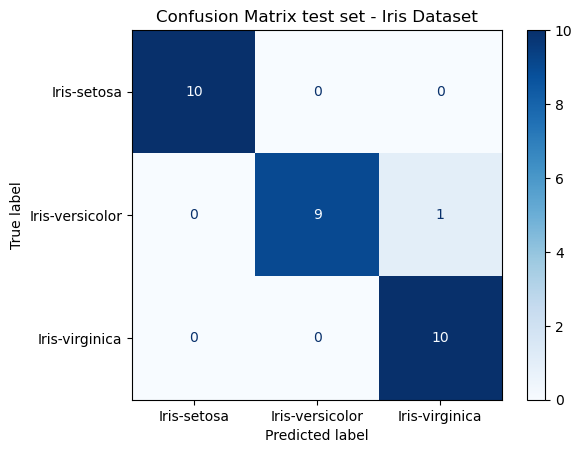

In [61]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix test set - Iris Dataset")
plt.show()

#### Accuracy test with Tranning Set

In [62]:
# Predict on Tranning set
y_train_pred = res_l2_lbfgs.predict(X_train)
# Evaluate performance
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
# Additional analysis
dfX = pd.DataFrame({'train':y_train,'pred':y_train_pred})
dfX['match'] = dfX['train'] == dfX['pred']
accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_lbfgs')
accurecy_set.append('traing set')

Accuracy: 0.975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.95      0.96        40
           2       0.95      0.97      0.96        40

    accuracy                           0.97       120
   macro avg       0.98      0.97      0.97       120
weighted avg       0.98      0.97      0.97       120



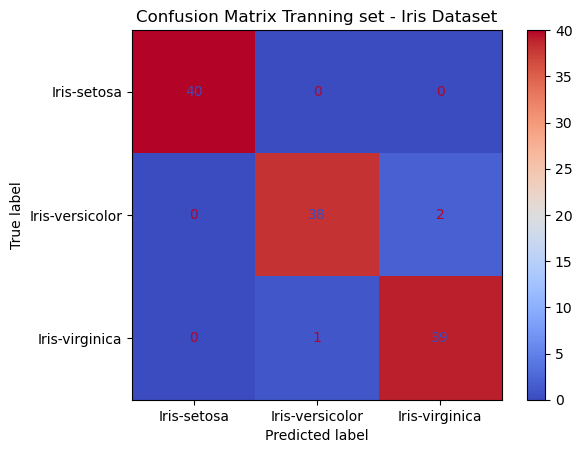

In [63]:
# Generate confusion matrix
cm = confusion_matrix(y_train, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

# Plot the confusion matrix
disp.plot(cmap=plt.cm.coolwarm)  #Try 'Blues', 'Oranges', 'coolwarm', 'plasma', etc.

plt.title("Confusion Matrix Tranning set - Iris Dataset")
plt.show()

Create model with 
- Solver = liblinear
- Regularizations = L1
- C = 1.0

In [64]:
Logistice = LogisticRegression(random_state=42,penalty='l1',solver='liblinear',max_iter=200,tol=0.001,fit_intercept=True)
res_l1_liblinear = Logistice.fit(X_train, y_train)

In [65]:
print(f'Totla number of classes: {res_l1_liblinear.classes_.size} and classes {res_l1_liblinear.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l1_liblinear.intercept_}')
print(f'Coefficient of the features in the decision function {res_l1_liblinear.coef_}')
print(f'Number of features: {res_l1_liblinear.n_features_in_}')
print(f'Names of features: {res_l1_liblinear.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l1_liblinear.n_iter_}')

Totla number of classes: 3 and classes [0 1 2]
Intercept (a.k.a. bias) added to the decision function: [0.         1.31406015 0.        ]
Coefficient of the features in the decision function [[ 0.          2.38152628 -2.66476661  0.        ]
 [ 0.2960441  -1.53800389  0.70389736 -1.56714014]
 [-2.5420693  -1.98684934  3.1485054   3.72679714]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[15 33 45]


In [66]:
# Predict on test set
y_test_pred = res_l1_liblinear.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# Additional analysis
dfX = pd.DataFrame({'test':y_test,'pred':y_test_pred})
dfX['match'] = dfX['test'] == dfX['pred']

accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l1_liblinear')
accurecy_set.append('test set')

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [67]:
# Predict on test set
y_train_pred = res_l1_liblinear.predict(X_train)
# Evaluate performance
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
# Additional analysis
dfX = pd.DataFrame({'train':y_train,'pred':y_train_pred})
dfX['match'] = dfX['train'] == dfX['pred']
accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l1_liblinear')
accurecy_set.append('traing set')

Accuracy: 0.9583333333333334

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.95      0.93      0.94        40
           2       0.93      0.95      0.94        40

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



### Confusion Matrix

In [68]:
# Confusion Matrix On test Set
cm = confusion_matrix(y_test, y_pred)

Create model with 
- Solver = liblinear
- Regularizations = L2
- C = 1.0

In [69]:
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='liblinear',max_iter=200,tol=0.001,fit_intercept=True)
res_l2_liblinear = Logistice.fit(X_train, y_train)

In [70]:
print(f'Totla number of classes: {res_l2_liblinear.classes_.size} and classes {res_l2_liblinear.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2_liblinear.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2_liblinear.coef_}')
print(f'Number of features: {res_l2_liblinear.n_features_in_}')
print(f'Names of features: {res_l2_liblinear.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2_liblinear.n_iter_}')

Totla number of classes: 3 and classes [0 1 2]
Intercept (a.k.a. bias) added to the decision function: [ 0.26786493  0.94157471 -1.13262172]
Coefficient of the features in the decision function [[ 0.40324089  1.39158088 -2.16391599 -0.98336008]
 [ 0.36981075 -1.49102026  0.57987074 -1.33450823]
 [-1.6169359  -1.32679182  2.31171004  2.26313144]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[6 6 5]


In [71]:
# Predict on test set
y_test_pred = res_l2_liblinear.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# Additional analysis
dfX = pd.DataFrame({'test':y_test,'pred':y_test_pred})
dfX['match'] = dfX['test'] == dfX['pred']

accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_liblinear')
accurecy_set.append('test set')

Accuracy: 0.9666666666666667

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.90      0.95        10
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [72]:
# Predict on test set
y_train_pred = res_l2_liblinear.predict(X_train)
# Evaluate performance
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
# Additional analysis
dfX = pd.DataFrame({'train':y_train,'pred':y_train_pred})
dfX['match'] = dfX['train'] == dfX['pred']
accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_liblinear')
accurecy_set.append('traing set')

Accuracy: 0.9583333333333334

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.97      0.90      0.94        40
           2       0.91      0.97      0.94        40

    accuracy                           0.96       120
   macro avg       0.96      0.96      0.96       120
weighted avg       0.96      0.96      0.96       120



Create model with 
- Solver = newton-cholesky
- Regularizations = L2
- C = 1.0

Conditions to choos ‘newton-cholesky’ is a good choice for n_samples >> n_features * n_classes

n_sampls = 150

n_features = 4

n_classes = 3

150 >> 4*3

So we can use newton-cholesky

In [73]:
Logistice = LogisticRegression(random_state=42,penalty='l2',solver='newton-cholesky',max_iter=200,tol=0.001,fit_intercept=True)
res_l2_newton_cholesky = Logistice.fit(X_train, y_train)

In [74]:
print(f'Totla number of classes: {res_l2_newton_cholesky.classes_.size} and classes {res_l2_newton_cholesky.classes_}')
print(f'Intercept (a.k.a. bias) added to the decision function: {res_l2_newton_cholesky.intercept_}')
print(f'Coefficient of the features in the decision function {res_l2_newton_cholesky.coef_}')
print(f'Number of features: {res_l2_newton_cholesky.n_features_in_}')
print(f'Names of features: {res_l2_newton_cholesky.feature_names_in_}')
print(f'Actual number of iterations for all classes:{res_l2_newton_cholesky.n_iter_}')

Totla number of classes: 3 and classes [0 1 2]
Intercept (a.k.a. bias) added to the decision function: [  7.25663456   5.50695661 -13.94433362]
Coefficient of the features in the decision function [[-0.53754935  0.78089297 -2.20434512 -0.92370653]
 [-0.27434573 -1.99302593  0.73552006 -1.23559586]
 [-0.28259652 -0.40604497  2.70430952  2.19141801]]
Number of features: 4
Names of features: ['SepalLengthCm' 'SepalWidthCm' 'PetalLengthCm' 'PetalWidthCm']
Actual number of iterations for all classes:[6 3 6]


In [75]:
# Predict on test set
y_test_pred = res_l2_newton_cholesky.predict(X_test)
# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))
# Additional analysis
dfX = pd.DataFrame({'test':y_test,'pred':y_test_pred})
dfX['match'] = dfX['test'] == dfX['pred']

accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_newton_cholesky')
accurecy_set.append('test set')

Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.80      0.89        10
           2       0.83      1.00      0.91        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [76]:
# Predict on test set
y_train_pred = res_l2_newton_cholesky.predict(X_train)
# Evaluate performance
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("\nClassification Report:\n", classification_report(y_train, y_train_pred))
# Additional analysis
dfX = pd.DataFrame({'train':y_train,'pred':y_train_pred})
dfX['match'] = dfX['train'] == dfX['pred']
accuracy_list.append(accuracy_score(y_test, y_test_pred))
accuracy_model.append('res_l2_newton_cholesky')
accurecy_set.append('traing set')

Accuracy: 0.95

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        40
           1       0.95      0.90      0.92        40
           2       0.90      0.95      0.93        40

    accuracy                           0.95       120
   macro avg       0.95      0.95      0.95       120
weighted avg       0.95      0.95      0.95       120



In [77]:
dfReport = pd.DataFrame({'accuracy_model':accuracy_model,
                         'accurecy_set':accurecy_set,'accuracy_list':accuracy_list})
dfReport

,accuracy_model,accurecy_set,accuracy_list
0,res_l2_lbfgs,test set,0.966667
1,res_l2_lbfgs,traing set,0.966667
2,res_l1_liblinear,test set,0.966667
3,res_l1_liblinear,traing set,0.966667
4,res_l2_liblinear,test set,0.966667
5,res_l2_liblinear,traing set,0.966667
6,res_l2_newton_cholesky,test set,0.933333
7,res_l2_newton_cholesky,traing set,0.933333


### Confustion matrix


#### ROC Curve

#### Cross Validations test

In [84]:
# Create dummy data
np.random.seed(42)
X = np.random.rand(100, 4)
y = np.random.randint(0, 2, 100)
X = sm.add_constant(X)
# Define variables for restricted model (only first two features)
X0 = X[:, [0, 1, 2]] # Intercept and 2 predictors
# Define variables for full model (all four features)
X1 = X # Intercept and 4 predictors

# 1. Fit the restricted model (M0)
model0 = sm.Logit(y, X0).fit()
model0 = sm.GLM(y, X0, family=sm.families.Binomial()).fit()
probs_model0 = model0.predict(X0)

# 2. Fit the full model (M1)
model1 = sm.Logit(y, X1).fit()
model1 = sm.GLM(y, X1, family=sm.families.Binomial()).fit()
probs_model1 = model1.predict(X1)
# 3. Calculate the test statistic (G)
G_statistic = model0.deviance - model1.deviance
print(f'D model0 {model0.deviance} - D model1 {model1.deviance}')

from sklearn.metrics import log_loss

D1 = 2 * log_loss(y, probs_model0, normalize=False)
print(f"Residual Deviance: {D1:.2f}")


Optimization terminated successfully.
         Current function value: 0.679499
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.675927
         Iterations 4
D model0 135.89976479200334 - D model1 135.18533482860116
Residual Deviance: 135.90
